<html><div style="font-size:7pt">This notebook may contain text, code and images generated by artificial intelligence. Used model: claude-sonnet-4-6, vision model: claude-sonnet-4-6, fast_model: None, endpoint: None, bia-bob version: 0.35.0.. It is good scientific practice to check the code and results it produces carefully. <a href="https://github.com/haesleinhuepf/bia-bob">Read more about code generation using bia-bob</a></div></html>

# Cell Segmentation Using the Watershed Algorithm

In this notebook, we will segment cells from a 2D membrane image using the **watershed algorithm**. The watershed algorithm treats the image as a topographic map and floods it from local minima, creating segmentation boundaries where the flooding from different sources meets.

In [1]:
import numpy as np
import stackview
from skimage.io import imread
from skimage.filters import gaussian
from skimage.morphology import white_tophat, disk
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.measure import label
from scipy.ndimage import distance_transform_edt

## Step 1: Load the Image

We load the 2D membrane image from disk and inspect it.

[[4496 5212 6863 ... 2917 2680 2642]
 [4533 5146 7555 ... 2843 2857 2748]
 [4640 6082 8452 ... 3372 3039 3128]
 ...
 [1339 1403 1359 ... 4458 4314 4795]
 [1473 1560 1622 ... 3967 4531 4204]
 [1380 1368 1649 ... 3091 3558 3682]]
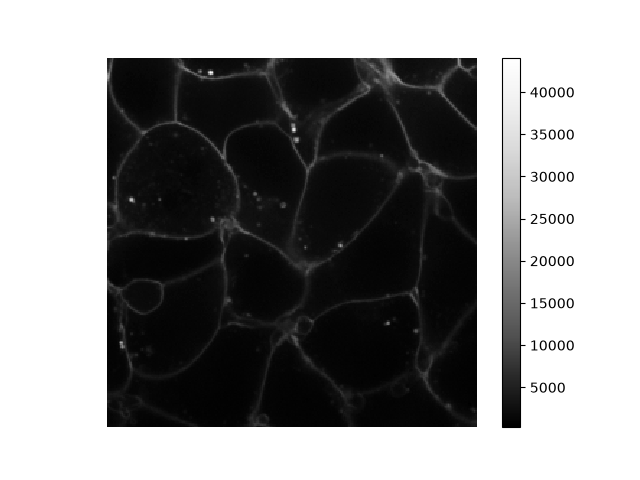
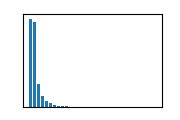

In [2]:
image = imread('data/membrane2d.tif')

stackview.insight(image)

## Step 2: Top-Hat Background Removal

We apply a white top-hat filter using `skimage.morphology.white_tophat` with a disk-shaped structuring element of radius 15. This replaces the pyclesperanto `cle.top_hat` call and removes uneven background illumination by subtracting the morphological opening from the original image, enhancing bright membrane structures.

[[2988 3704 5355 ...  239    2    0]
 [3025 3638 6047 ...  165  215  106]
 [3132 4574 6944 ...  694  397  486]
 ...
 [ 141  205  161 ... 3452 3308 3789]
 [ 275  362  424 ... 2961 3525 3198]
 [ 182  170  451 ... 2085 2552 2676]]
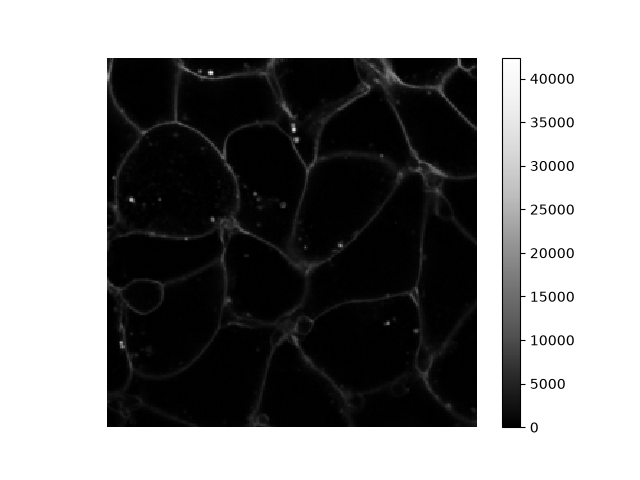
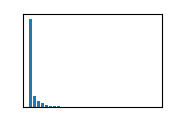

In [3]:
footprint = disk(15)

background_corrected = white_tophat(image, footprint=footprint)

stackview.insight(background_corrected)

## Step 3: Preprocess the Image

We apply a Gaussian blur to reduce noise in the background-corrected membrane image. This helps improve the quality of subsequent thresholding and distance transform steps.

[[4079.62152008 4197.11981323 4170.00031702 ...  560.9269304
   536.59290675  521.47423423]
 [4231.87409617 4314.92282259 4243.06380886 ...  830.90649518
   810.93611301  797.68404609]
 [4439.50316791 4475.38817124 4344.24473726 ... 1193.22026206
  1170.68678004 1152.13067549]
 ...
 [ 257.35485998  299.40976486  362.15125851 ... 2615.79795822
  2754.43807656 2871.63123253]
 [ 268.42088222  316.29919446  385.63755988 ... 2591.68001204
  2735.49960975 2855.132154  ]
 [ 279.01437498  333.04706949  409.52041617 ... 2522.92658199
  2669.04893512 2789.27199169]]
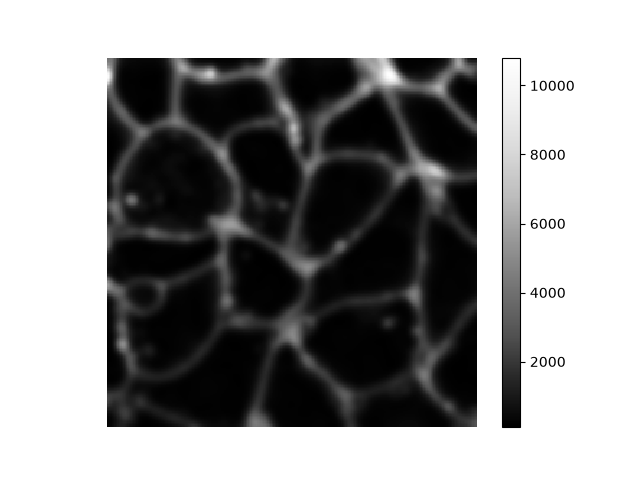
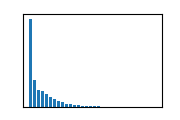

In [4]:
blurred = gaussian(background_corrected.astype(float), sigma=3)

stackview.insight(blurred)

## Step 4: Threshold the Image to Create a Binary Mask

We threshold to separate cell interiors from membranes. Since membranes appear bright, the cell interiors will be the dark regions (below the threshold). We invert the binary image so that cell interiors are `True`.

C:\structure\code\embl-bia-2026\.venv\Lib\site-packages\stackview\_static_view.py:107: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  h, _ = np.histogram(self, bins=num_bins)


[[False False False ...  True  True  True]
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]
 ...
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]]
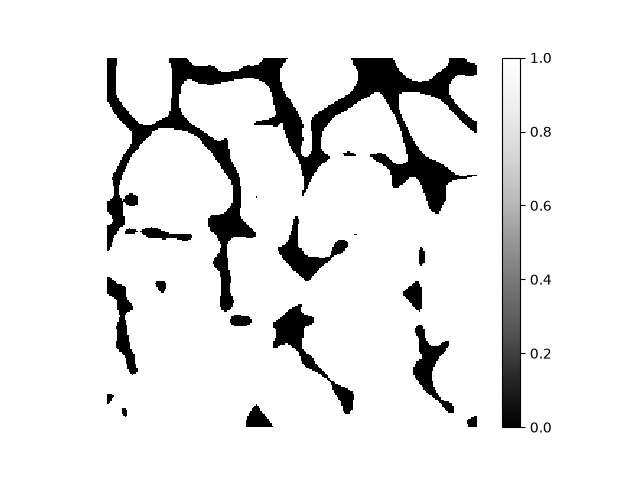
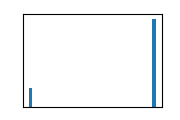

In [5]:
threshold = 2000

binary = blurred < threshold  # cell interiors are dark

stackview.insight(binary)

## Step 5: Compute the Distance Transform

We compute the Euclidean distance transform of the binary mask. Each pixel in the result holds the distance to the nearest background (membrane) pixel. Peaks in this map correspond to cell centers.

[[ 0.          0.          0.         ...  4.          4.
   4.12310563]
 [ 0.          0.          0.         ...  3.          3.
   3.16227766]
 [ 0.          0.          0.         ...  2.          2.
   2.23606798]
 ...
 [12.20655562 11.40175425 10.63014581 ...  0.          0.
   0.        ]
 [12.80624847 12.04159458 11.3137085  ...  0.          0.
   0.        ]
 [13.45362405 12.72792206 12.04159458 ...  0.          0.
   0.        ]]
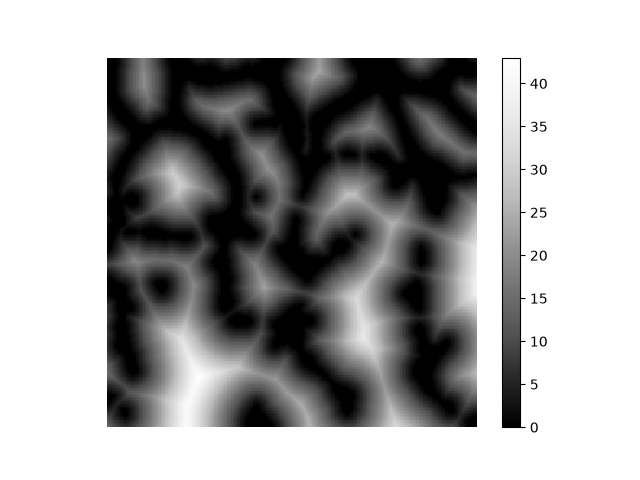
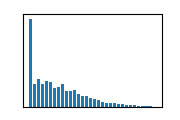

In [6]:
distance = distance_transform_edt(binary)

stackview.insight(distance)

## Step 6: Detect Local Maxima as Seed Points (Markers)

We find local maxima in the distance map. These correspond to the centers of the cells and will serve as seed points (markers) for the watershed algorithm.

Number of detected seed points (cells): 27


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
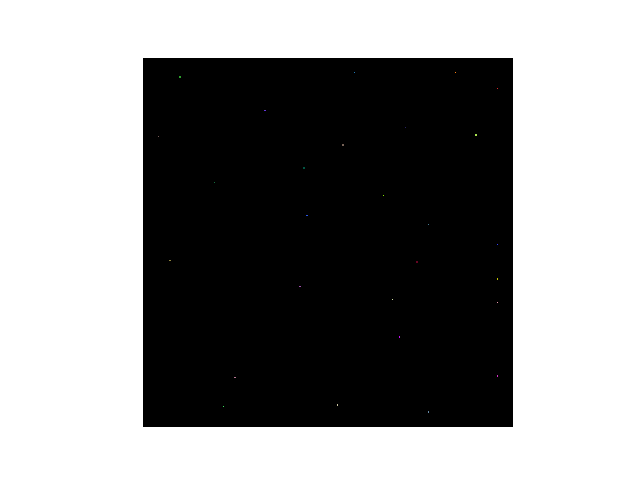

In [7]:
coords = peak_local_max(distance, min_distance=10, labels=binary)

mask = np.zeros(distance.shape, dtype=bool)

mask[tuple(coords.T)] = True

markers = label(mask)

print('Number of detected seed points (cells):', markers.max())

stackview.insight(markers)

## Step 7: Apply the Watershed Algorithm

We apply the watershed algorithm on the inverted distance map (so that peaks become valleys), using the detected markers as seeds and the binary mask to constrain segmentation to cell regions.

Number of segmented cells: 27


[[ 3  3  3 ...  4  4  4]
 [ 3  3  3 ...  4  4  4]
 [ 3  3  3 ...  4  4  4]
 ...
 [26 26 26 ... 27 23 23]
 [26 26 26 ... 27 27 27]
 [26 26 26 ... 27 27 27]]
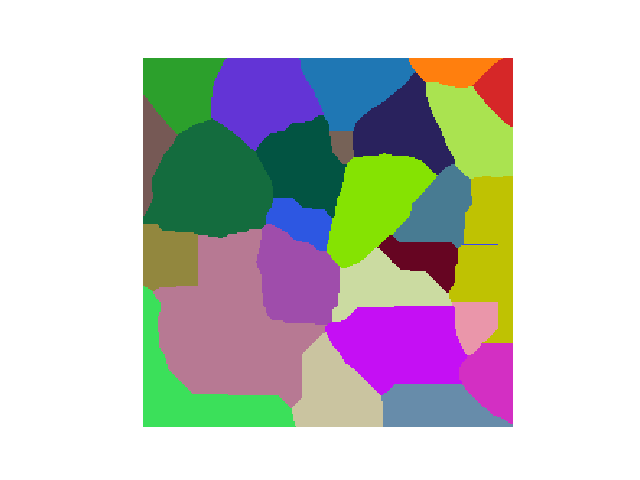

In [8]:
labels = watershed(-distance, markers)

print('Number of segmented cells:', labels.max())

stackview.insight(labels)

## Step 8: Visualize the Result with `stackview.animate_curtain`

We use `stackview.animate_curtain` to display the original membrane image alongside the segmentation label image. This animated curtain view allows us to interactively compare the raw image with the segmented cells.


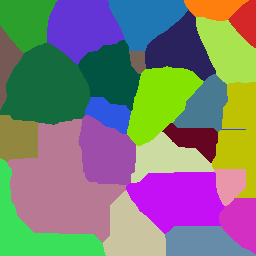

In [9]:
stackview.animate_curtain(image, labels)

## Exercise
Modify the threshold and the Gaussian blur sigma to improve the segmentation result.